In [16]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

# --- CONFIG ---
IMG_SIZE = 224
BATCH_SIZE = 32
LATENT_DIM = 128
EPOCHS = 50
DATA_DIR = r"C:\Users\User\Downloads\Skin-disease-dataset\mixed"  # <-- Change this

# --- IMAGE DATA AUGMENTATION ---
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    vertical_flip=True
)

train_gen = datagen.flow_from_directory(
    directory=os.path.dirname(DATA_DIR),  # parent folder
    classes=[os.path.basename(DATA_DIR)],  # target folder only
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode=None,
    shuffle=True
)

# --- ENCODER ---
def build_encoder():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.Conv2D(64, 4, strides=2, padding='same', activation='relu')(inputs)
    x = layers.Conv2D(128, 4, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2D(256, 4, strides=2, padding='same', activation='relu')(x)
    x = layers.Flatten()(x)
    z = layers.Dense(LATENT_DIM)(x)
    return Model(inputs, z, name="Encoder")

# --- DECODER ---
def build_decoder():
    inputs = layers.Input(shape=(LATENT_DIM,))
    x = layers.Dense((IMG_SIZE//8)*(IMG_SIZE//8)*256)(inputs)
    x = layers.Reshape((IMG_SIZE//8, IMG_SIZE//8, 256))(x)
    x = layers.Conv2DTranspose(128, 4, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2DTranspose(64, 4, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2DTranspose(3, 4, strides=2, padding='same', activation='sigmoid')(x)
    return Model(inputs, x, name="Decoder")

# --- DISCRIMINATOR ---
def build_discriminator():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.Conv2D(64, 4, strides=2, padding='same', activation='leaky_relu')(inputs)
    x = layers.Conv2D(128, 4, strides=2, padding='same', activation='leaky_relu')(x)
    x = layers.Conv2D(256, 4, strides=2, padding='same', activation='leaky_relu')(x)
    features = layers.GlobalAveragePooling2D()(x)
    validity = layers.Dense(1, activation='sigmoid')(features)
    return Model(inputs, [validity, features], name="Discriminator")

# --- MODEL INITIALIZATION ---
encoder = build_encoder()
decoder = build_decoder()
discriminator = build_discriminator()

# Combined Generator (G = GE + GD)
input_img = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
z = encoder(input_img)
x_hat = decoder(z)
generator = Model(input_img, x_hat, name="Generator")

# Encoder for generated image
z_hat = encoder(x_hat)

# --- LOSSES ---
bce = tf.keras.losses.BinaryCrossentropy()

def adversarial_loss(real_feat, fake_feat):
    return tf.reduce_mean(tf.square(real_feat - fake_feat))

def contextual_loss(real_img, recon_img):
    return tf.reduce_mean(tf.abs(real_img - recon_img))

def encoder_loss(z, z_hat):
    return tf.reduce_mean(tf.square(z - z_hat))

# --- OPTIMIZERS ---
g_opt = Adam(1e-4)
d_opt = Adam(1e-4)

# --- TRAINING LOOP ---
@tf.function
def train_step(images):
    with tf.GradientTape(persistent=True) as tape:
        z = encoder(images)
        x_hat = decoder(z)
        z_hat = encoder(x_hat)

        # Discriminator outputs
        real_pred, real_feat = discriminator(images)
        fake_pred, fake_feat = discriminator(x_hat)

        # Losses
        d_loss_real = bce(tf.ones_like(real_pred), real_pred)
        d_loss_fake = bce(tf.zeros_like(fake_pred), fake_pred)
        d_loss = d_loss_real + d_loss_fake

        adv_loss = adversarial_loss(real_feat, fake_feat)
        con_loss = contextual_loss(images, x_hat)
        enc_loss = encoder_loss(z, z_hat)
        g_loss = adv_loss + con_loss + enc_loss

    # Backpropagation
    d_grads = tape.gradient(d_loss, discriminator.trainable_variables)
    g_grads = tape.gradient(g_loss, generator.trainable_variables + encoder.trainable_variables)

    d_opt.apply_gradients(zip(d_grads, discriminator.trainable_variables))
    g_opt.apply_gradients(zip(g_grads, generator.trainable_variables + encoder.trainable_variables))

    return d_loss, g_loss

# --- TRAINING ---
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    for step, batch in enumerate(train_gen):
        d_loss, g_loss = train_step(batch)
        if step % 10 == 0:
            print(f"Step {step}: D_loss={d_loss.numpy():.4f}, G_loss={g_loss.numpy():.4f}")
        if step >= len(train_gen):
            break

# --- SAVE MODELS ---
encoder.save("ganomaly_encoder.h5")
decoder.save("ganomaly_decoder.h5")
discriminator.save("ganomaly_discriminator.h5")
generator.save("ganomaly_generator.h5")


Found 41096 images belonging to 1 classes.

Epoch 1/50
Step 0: D_loss=1.3850, G_loss=0.2524
Step 10: D_loss=1.2982, G_loss=0.2255
Step 20: D_loss=1.0983, G_loss=0.2401
Step 30: D_loss=0.7127, G_loss=0.2438
Step 40: D_loss=0.5310, G_loss=0.2883
Step 50: D_loss=0.3599, G_loss=0.3515
Step 60: D_loss=0.4139, G_loss=0.3858
Step 70: D_loss=3.9337, G_loss=0.3168
Step 80: D_loss=1.4723, G_loss=0.2615
Step 90: D_loss=1.7981, G_loss=0.2468
Step 100: D_loss=1.5438, G_loss=0.2476
Step 110: D_loss=1.4139, G_loss=0.2233
Step 120: D_loss=1.4539, G_loss=0.2116
Step 130: D_loss=1.3794, G_loss=0.2269
Step 140: D_loss=1.4026, G_loss=0.2273
Step 150: D_loss=1.3458, G_loss=0.2303
Step 160: D_loss=1.3470, G_loss=0.2346
Step 170: D_loss=1.4087, G_loss=0.2514
Step 180: D_loss=1.2552, G_loss=0.2144
Step 190: D_loss=1.2708, G_loss=0.2351
Step 200: D_loss=1.2587, G_loss=0.2223
Step 210: D_loss=1.3113, G_loss=0.2330
Step 220: D_loss=1.2353, G_loss=0.2386
Step 230: D_loss=1.2462, G_loss=0.2357
Step 240: D_loss=1.3

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tqdm import tqdm # For a nice progress bar

# --- CONFIG ---
IMG_SIZE = 224
BATCH_SIZE = 32
LATENT_DIM = 128
EPOCHS = 50
DATA_DIR = r"C:\Users\User\Downloads\Skin-disease-dataset\mixed"  # <-- Change this

# Loss weights - Crucial for guiding the model
W_ADV = 1.0
W_CON = 50.0  # Make reconstruction loss the top priority
W_ENC = 1.0

# --- IMAGE DATA AUGMENTATION ---
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    vertical_flip=True
)

train_gen = datagen.flow_from_directory(
    directory=os.path.dirname(DATA_DIR),  # parent folder
    classes=[os.path.basename(DATA_DIR)],  # target folder only
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode=None,
    shuffle=True
)

# --- ENCODER ---
def build_encoder():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.Conv2D(64, 4, strides=2, padding='same')(inputs)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Conv2D(128, 4, strides=2, padding='same')(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Conv2D(256, 4, strides=2, padding='same')(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Flatten()(x)
    z = layers.Dense(LATENT_DIM)(x)
    return Model(inputs, z, name="Encoder")

# --- DECODER ---
def build_decoder():
    inputs = layers.Input(shape=(LATENT_DIM,))
    x = layers.Dense((IMG_SIZE//8)*(IMG_SIZE//8)*256)(inputs)
    x = layers.Reshape((IMG_SIZE//8, IMG_SIZE//8, 256))(x)
    x = layers.Conv2DTranspose(128, 4, strides=2, padding='same')(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Conv2DTranspose(64, 4, strides=2, padding='same')(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    # The final layer uses sigmoid to output values between [0, 1]
    x = layers.Conv2DTranspose(3, 4, strides=2, padding='same', activation='sigmoid')(x)
    return Model(inputs, x, name="Decoder")

# --- DISCRIMINATOR ---
def build_discriminator():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.Conv2D(64, 4, strides=2, padding='same')(inputs)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Conv2D(128, 4, strides=2, padding='same')(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Conv2D(256, 4, strides=2, padding='same')(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    features = layers.GlobalAveragePooling2D()(x)
    validity = layers.Dense(1, activation='sigmoid')(features)
    return Model(inputs, [validity, features], name="Discriminator")

# --- MODEL INITIALIZATION ---
encoder = build_encoder()
decoder = build_decoder()
discriminator = build_discriminator()

# --- OPTIMIZERS ---
g_opt = Adam(1e-4, beta_1=0.5)
d_opt = Adam(1e-4, beta_1=0.5)

# --- LOSSES ---
bce = tf.keras.losses.BinaryCrossentropy()
mse = tf.keras.losses.MeanSquaredError()
mae = tf.keras.losses.MeanAbsoluteError()

# --- TRAINING LOOP ---
@tf.function
def train_step(images):
    # Define the variables to be trained by the generator optimizer
    g_vars = encoder.trainable_variables + decoder.trainable_variables

    with tf.GradientTape() as g_tape, tf.GradientTape() as d_tape:
        # Reconstruct images
        z = encoder(images, training=True)
        x_hat = decoder(z, training=True)

        # Discriminator outputs
        real_pred, real_feat = discriminator(images, training=True)
        fake_pred, fake_feat = discriminator(x_hat, training=True)

        # Discriminator loss
        d_loss_real = bce(tf.ones_like(real_pred), real_pred)
        d_loss_fake = bce(tf.zeros_like(fake_pred), fake_pred)
        d_loss = d_loss_real + d_loss_fake

        # Generator losses
        adv_loss = mse(real_feat, fake_feat)
        con_loss = mae(images, x_hat)
        
        # Encoder loss (latent vector consistency)
        z_hat = encoder(x_hat, training=True)
        enc_loss = mse(z, z_hat)
        
        # Total Generator loss with weighting
        g_loss = (W_ADV * adv_loss) + (W_CON * con_loss) + (W_ENC * enc_loss)

    # Backpropagation
    d_grads = d_tape.gradient(d_loss, discriminator.trainable_variables)
    g_grads = g_tape.gradient(g_loss, g_vars)

    d_opt.apply_gradients(zip(d_grads, discriminator.trainable_variables))
    g_opt.apply_gradients(zip(g_grads, g_vars))

    return d_loss, g_loss, con_loss # Return con_loss to monitor reconstruction

# --- TRAINING ---
print("🚀 Starting training...")
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    
    # Use tqdm for a progress bar
    pbar = tqdm(train_gen, total=len(train_gen), desc="Training")
    
    for i, batch in enumerate(pbar):
        d_loss, g_loss, con_loss = train_step(batch)
        
        # Update progress bar description
        pbar.set_description(
            f"D_loss={d_loss.numpy():.4f} | "
            f"G_loss={g_loss.numpy():.4f} | "
            f"Recon_loss={con_loss.numpy():.4f}"
        )
        
        # The generator already breaks the loop, this is a fail-safe
        if i >= len(train_gen) -1:
            break

# --- SAVE MODELS ---
print("\n✅ Training complete. Saving models...")
# Create a Generator model for easy inference later
input_img = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
z = encoder(input_img)
x_hat = decoder(z)
generator = Model(input_img, x_hat, name="Generator")

encoder.save("ganomaly_encoder.h5")
decoder.save("ganomaly_decoder.h5")
discriminator.save("ganomaly_discriminator.h5")
generator.save("ganomaly_generator.h5")
print("All models saved successfully.")

Found 41096 images belonging to 1 classes.
🚀 Starting training...

Epoch 1/50


D_loss=0.6061 | G_loss=2.9680 | Recon_loss=0.0578: 100%|█████████▉| 1284/1285 [09:50<00:00,  2.18it/s]



Epoch 2/50


D_loss=0.5358 | G_loss=2.8805 | Recon_loss=0.0560: 100%|█████████▉| 1284/1285 [09:48<00:00,  2.18it/s]



Epoch 3/50


...

D_loss=0.0379 | G_loss=1.9615 | Recon_loss=0.0381: 100%|█████████▉| 1284/1285 [09:39<00:00,  2.22it/s]



Epoch 50/50


D_loss=0.0421 | G_loss=1.6374 | Recon_loss=0.0316: 100%|█████████▉| 1284/1285 [09:39<00:00,  2.22it/s]


✅ Training complete. Saving models...


All models saved successfully.


In [4]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

# --- CONFIG ---
IMG_SIZE = 224
BATCH_SIZE = 16
LATENT_DIM = 128
EPOCHS = 30
DATA_DIR = r"C:\Users\User\Downloads\Skin-disease-dataset\mixed"  # <-- Change this
PRETRAINED_ENCODER_PATH = "four_skin_disease_detection.h5"  # Path to your pretrained encoder model

# --- IMAGE DATA AUGMENTATION ---
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

train_gen = datagen.flow_from_directory(
    directory=os.path.dirname(DATA_DIR),
    classes=[os.path.basename(DATA_DIR)],
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode=None,
    shuffle=True
)

# --- LOAD PRETRAINED ENCODER AND ADD LAYERS ---
base_encoder = tf.keras.models.load_model(PRETRAINED_ENCODER_PATH)
base_encoder.trainable = True  # Set False if you want to freeze pretrained layers initially

# Suppose base_encoder outputs a vector, add layers on top for GANomaly
x = base_encoder.output
x = layers.Dense(256, activation='relu')(x)
z = layers.Dense(LATENT_DIM, name="latent_vector")(x)
encoder = Model(base_encoder.input, z, name="Encoder")

# --- DECODER ---
def build_decoder():
    inputs = layers.Input(shape=(LATENT_DIM,))
    x = layers.Dense((IMG_SIZE // 8) * (IMG_SIZE // 8) * 256, activation='relu')(inputs)
    x = layers.Reshape((IMG_SIZE // 8, IMG_SIZE // 8, 256))(x)  # (28, 28, 256)

    x = layers.Conv2DTranspose(128, 4, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2DTranspose(64, 4, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2DTranspose(3, 4, strides=2, padding='same', activation='sigmoid')(x)
    return Model(inputs, x, name="Decoder")

decoder = build_decoder()

# --- DISCRIMINATOR ---
def build_discriminator():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.Conv2D(64, 4, strides=2, padding='same')(inputs)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Conv2D(128, 4, strides=2, padding='same')(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Conv2D(256, 4, strides=2, padding='same')(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    features = layers.GlobalAveragePooling2D()(x)
    validity = layers.Dense(1, activation='sigmoid')(features)
    return Model(inputs, [validity, features], name="Discriminator")

discriminator = build_discriminator()

# --- GENERATOR (Encoder + Decoder) ---
input_img = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
z = encoder(input_img)
x_hat = decoder(z)
generator = Model(input_img, x_hat, name="Generator")

# Encoder for generated image
z_hat = encoder(x_hat)

# --- LOSSES ---
bce = tf.keras.losses.BinaryCrossentropy()

def adversarial_loss(real_feat, fake_feat):
    return tf.reduce_mean(tf.square(real_feat - fake_feat))

def contextual_loss(real_img, recon_img):
    return tf.reduce_mean(tf.abs(real_img - recon_img))

def encoder_loss(z, z_hat):
    return tf.reduce_mean(tf.square(z - z_hat))

# --- OPTIMIZERS ---
g_opt = Adam(1e-4)
d_opt = Adam(1e-4)

# --- TRAINING STEP ---
@tf.function
def train_step(images):
    with tf.GradientTape(persistent=True) as tape:
        z = encoder(images)
        x_hat = decoder(z)
        z_hat = encoder(x_hat)

        real_pred, real_feat = discriminator(images)
        fake_pred, fake_feat = discriminator(x_hat)

        d_loss_real = bce(tf.ones_like(real_pred), real_pred)
        d_loss_fake = bce(tf.zeros_like(fake_pred), fake_pred)
        d_loss = d_loss_real + d_loss_fake

        adv_loss = adversarial_loss(real_feat, fake_feat)
        con_loss = contextual_loss(images, x_hat)
        enc_loss = encoder_loss(z, z_hat)
        g_loss = adv_loss + con_loss + enc_loss

    d_grads = tape.gradient(d_loss, discriminator.trainable_variables)
    g_grads = tape.gradient(g_loss, generator.trainable_variables)


    d_opt.apply_gradients(zip(d_grads, discriminator.trainable_variables))
    g_opt.apply_gradients(zip(g_grads, generator.trainable_variables + encoder.trainable_variables))

    return d_loss, g_loss

# --- TRAINING LOOP ---
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    for step, batch in enumerate(train_gen):
        d_loss, g_loss = train_step(batch)
        if step % 10 == 0:
            print(f"Step {step}: D_loss={d_loss.numpy():.4f}, G_loss={g_loss.numpy():.4f}")
        if step >= len(train_gen):
            break

# --- SAVE MODELS ---
encoder.save("ganomaly_encoder_extended.h5")
decoder.save("ganomaly_decoder_extended.h5")
discriminator.save("ganomaly_discriminator_extended.h5")
generator.save("ganomaly_generator_extended.h5")


Found 41096 images belonging to 1 classes.

Epoch 1/30
Step 0: D_loss=1.3912, G_loss=0.2400
Step 10: D_loss=1.2548, G_loss=0.2827
Step 20: D_loss=0.9947, G_loss=0.2408
Step 30: D_loss=0.7179, G_loss=0.2334
Step 40: D_loss=0.5883, G_loss=0.3135
Step 50: D_loss=0.3791, G_loss=0.3190
Step 60: D_loss=0.3951, G_loss=0.3830
Step 70: D_loss=0.8933, G_loss=0.2856
Step 80: D_loss=2.6635, G_loss=0.2468
Step 90: D_loss=1.7299, G_loss=0.2308
Step 100: D_loss=1.3212, G_loss=0.2732
Step 110: D_loss=1.3437, G_loss=0.2451
Step 120: D_loss=1.0902, G_loss=0.2461
Step 130: D_loss=1.1660, G_loss=0.2524
Step 140: D_loss=1.0820, G_loss=0.2233
Step 150: D_loss=1.1422, G_loss=0.2418
Step 160: D_loss=1.0611, G_loss=0.2325
Step 170: D_loss=1.0207, G_loss=0.2244
Step 180: D_loss=0.9287, G_loss=0.2448
Step 190: D_loss=0.8852, G_loss=0.2571
Step 200: D_loss=0.9296, G_loss=0.2349
Step 210: D_loss=0.9824, G_loss=0.2421
Step 220: D_loss=0.8594, G_loss=0.2771
Step 230: D_loss=0.8476, G_loss=0.2424
Step 240: D_loss=1.1

In [5]:
from tensorflow.keras.models import load_model

encoder = load_model("ganomaly_encoder_extended.h5")
decoder = load_model("ganomaly_decoder_extended.h5")
discriminator = load_model("ganomaly_discriminator_extended.h5")
generator = load_model("ganomaly_generator_extended.h5")


In [6]:
import numpy as np

def compute_anomaly_score(image, encoder, decoder):
    image = np.expand_dims(image, axis=0)  # add batch dim
    latent_real = encoder.predict(image)
    reconstructed = decoder.predict(latent_real)
    latent_fake = encoder.predict(reconstructed)

    # L2 norm between original and reconstructed latent
    score = np.linalg.norm(latent_real - latent_fake)
    return score


In [7]:
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def load_test_images(test_dir, img_size=(224, 224)):
    images, labels = [], []
    for label_dir in os.listdir(test_dir):  # e.g., 'Normal', 'Anomaly'
        label_path = os.path.join(test_dir, label_dir)
        for fname in os.listdir(label_path):
            img_path = os.path.join(label_path, fname)
            img = load_img(img_path, target_size=img_size)
            img_array = img_to_array(img) / 255.0
            images.append(img_array)
            labels.append(0 if label_dir.lower() == 'normal' else 1)
    return np.array(images), np.array(labels)


In [9]:
images, labels = load_test_images(r"C:\Users\User\Downloads\Skin-disease-dataset\anomaly-test")
scores = np.array([compute_anomaly_score(img, encoder, decoder) for img in images])


1/1 [==============================] - 0s 16ms/step


In [10]:
from sklearn.metrics import confusion_matrix, classification_report

threshold = np.percentile(scores[labels == 0], 95)  # e.g., 95th percentile of normal scores
preds = (scores > threshold).astype(int)

print(confusion_matrix(labels, preds))
print(classification_report(labels, preds))


[[476   0]
 [630   0]]
              precision    recall  f1-score   support

           0       0.43      1.00      0.60       476
           1       0.00      0.00      0.00       630

    accuracy                           0.43      1106
   macro avg       0.22      0.50      0.30      1106
weighted avg       0.19      0.43      0.26      1106



C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

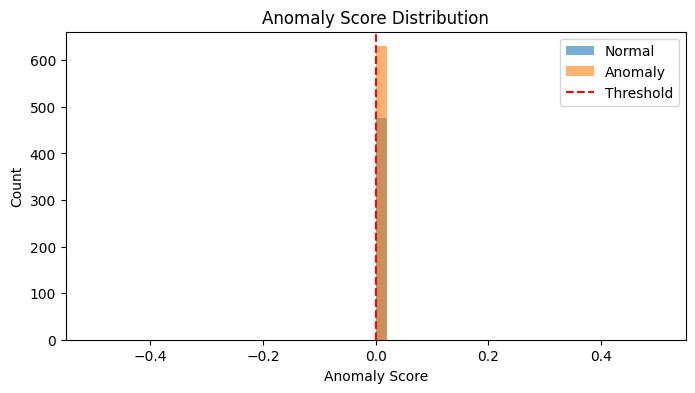

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(scores[labels == 0], bins=50, alpha=0.6, label='Normal')
plt.hist(scores[labels == 1], bins=50, alpha=0.6, label='Anomaly')
plt.axvline(threshold, color='red', linestyle='--', label='Threshold')
plt.legend()
plt.title('Anomaly Score Distribution')
plt.xlabel('Anomaly Score')
plt.ylabel('Count')
plt.show()


✅ Model loaded successfully.

Calculating scores for 476 NORMAL images...


Normal Scores: 100%|██████████| 476/476 [00:38<00:00, 12.50it/s]



Calculating scores for 570 ANOMALY images...


Anomaly Scores: 100%|██████████| 570/570 [00:53<00:00, 10.74it/s]


📊 Anomaly Score Statistics
Normal Images Score:
  Min:   0.0540
  Max:   0.8292
  Avg:   0.3593

Anomaly Images Score:
  Min:   0.0606
  Max:   0.8119
  Avg:   0.3878

💡 A plot has been generated. Look at the 'valley' between the blue and red distributions.
   Choose a new threshold value from that valley.


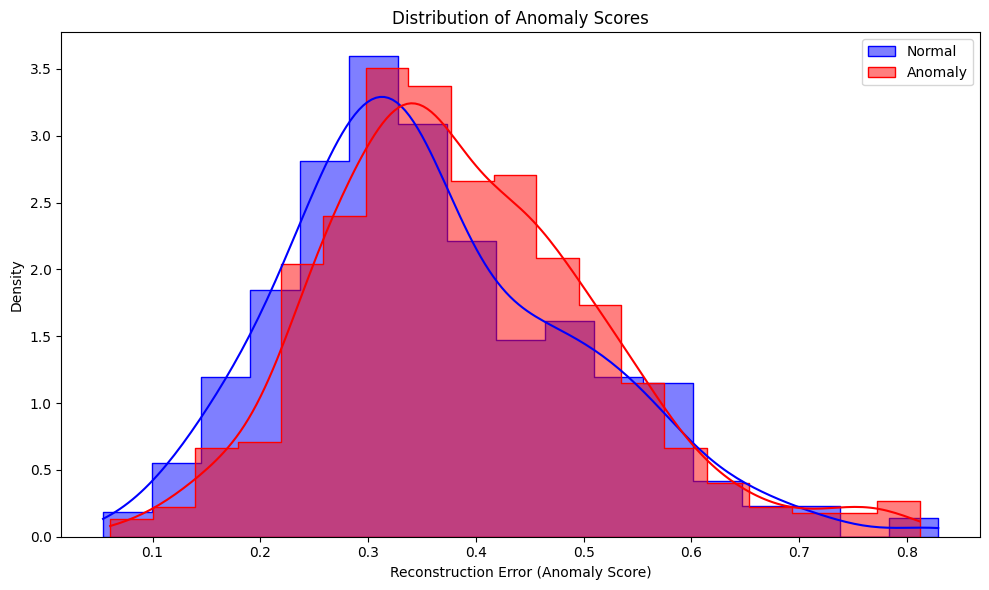

In [16]:
import tensorflow as tf
import numpy as np
import cv2
import os
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

## 1. Configuration & Model Loading
# ==============================================================================
IMAGE_SIZE = (224, 224)  # Must match your model's input size
TEST_DATA_DIR = r'C:\Users\User\Downloads\Skin-disease-dataset\anomaly-test' 

try:
    generator = tf.keras.models.load_model("ganomaly_generator.h5", compile=False)
    print("✅ Model loaded successfully.")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    exit()

## 2. Helper Functions (Slightly modified to only return the score)
# ==============================================================================
def get_image_score(image_path: str, size: tuple) -> float | None:
    """Preprocesses a single image and calculates its anomaly score."""
    # Preprocess
    img = cv2.imread(image_path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    img = (img.astype(np.float32) - 127.5) / 127.5
    img_tensor = np.expand_dims(img, axis=0)
    
    # Predict and calculate score
    reconstructed_img = generator.predict(img_tensor, verbose=0)
    reconstruction_error = np.mean(np.abs(img_tensor - reconstructed_img))
    return float(reconstruction_error)

## 3. Score Calculation
# ==============================================================================
normal_scores = []
anomaly_scores = []

# --- Process Normal Images ---
normal_path = os.path.join(TEST_DATA_DIR, 'Normal')
normal_files = [os.path.join(normal_path, f) for f in os.listdir(normal_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
print(f"\nCalculating scores for {len(normal_files)} NORMAL images...")

for file_path in tqdm(normal_files, desc="Normal Scores"):
    score = get_image_score(file_path, IMAGE_SIZE)
    if score is not None:
        normal_scores.append(score)

# --- Process Anomaly Images ---
anomaly_path = os.path.join(TEST_DATA_DIR, 'Anomaly')
anomaly_files = [os.path.join(anomaly_path, f) for f in os.listdir(anomaly_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
print(f"\nCalculating scores for {len(anomaly_files)} ANOMALY images...")

for file_path in tqdm(anomaly_files, desc="Anomaly Scores"):
    score = get_image_score(file_path, IMAGE_SIZE)
    if score is not None:
        anomaly_scores.append(score)
        
## 4. Analyze and Visualize
# ==============================================================================
if not normal_scores or not anomaly_scores:
    print("\n❌ Could not find images to process. Check your TEST_DATA_DIR.")
else:
    # --- Print Statistics ---
    print("\n" + "="*50)
    print("📊 Anomaly Score Statistics")
    print("="*50)
    print(f"Normal Images Score:")
    print(f"  Min:   {np.min(normal_scores):.4f}")
    print(f"  Max:   {np.max(normal_scores):.4f}")
    print(f"  Avg:   {np.mean(normal_scores):.4f}")
    print("\nAnomaly Images Score:")
    print(f"  Min:   {np.min(anomaly_scores):.4f}")
    print(f"  Max:   {np.max(anomaly_scores):.4f}")
    print(f"  Avg:   {np.mean(anomaly_scores):.4f}")
    print("="*50)

    # --- Plot Histogram ---
    plt.figure(figsize=(10, 6))
    sns.histplot(normal_scores, color='blue', label='Normal', kde=True, stat="density", element="step")
    sns.histplot(anomaly_scores, color='red', label='Anomaly', kde=True, stat="density", element="step")
    plt.title('Distribution of Anomaly Scores')
    plt.xlabel('Reconstruction Error (Anomaly Score)')
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    print("\n💡 A plot has been generated. Look at the 'valley' between the blue and red distributions.")
    print("   Choose a new threshold value from that valley.")
    plt.show()

In [13]:
import tensorflow as tf
import numpy as np
import cv2
import os
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

print(f"Using TensorFlow version: {tf.__version__}")

## 1. Configuration & Model Loading
# ==============================================================================
# --- Parameters ---
# IMPORTANT: Adjust this to the input size your models were trained on.
IMAGE_SIZE = (224, 224) 
# The directory containing 'Normal' and 'Anomaly' subfolders.
TEST_DATA_DIR = r'C:\Users\User\Downloads\Skin-disease-dataset\anomaly-test' 
# This threshold is critical for classification. You must tune this value based
# on the anomaly scores you observe on a validation set. A higher threshold
# makes the model less sensitive to anomalies.
ANOMALY_THRESHOLD = 0.2

# --- Load Models ---
# Using compile=False speeds up loading for inference.
try:
    # The generator (autoencoder) is used for reconstruction.
    generator = tf.keras.models.load_model("ganomaly_generator.h5", compile=False)
    print("✅ Models loaded successfully.")
except Exception as e:
    print(f"❌ Error loading models: {e}")
    print("Please ensure the .h5 files are in the same directory as this script.")
    exit()

## 2. Helper Functions
# ==============================================================================
def preprocess_image(image_path: str, size: tuple) -> np.ndarray:
    """Loads, resizes, and normalizes an image."""
    img = cv2.imread(image_path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    # Normalize images to [-1, 1], a common practice for GANs.
    # If your model was trained on [0, 1], use `img / 255.0`.
    img = (img.astype(np.float32) - 127.5) / 127.5
    # Add a batch dimension
    return np.expand_dims(img, axis=0)

def calculate_anomaly_score(original_img: np.ndarray) -> float:
    """Calculates the reconstruction error (L1/MAE) as the anomaly score."""
    reconstructed_img = generator.predict(original_img, verbose=0)
    # Calculate the Mean Absolute Error between the original and reconstructed images.
    reconstruction_error = np.mean(np.abs(original_img - reconstructed_img))
    return float(reconstruction_error)

def plot_confusion_matrix(y_true, y_pred, class_names):
    """Generates and displays a confusion matrix plot."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

## 3. Main Evaluation Logic
# ==============================================================================
y_true = [] # Ground truth labels (0 for Normal, 1 for Anomaly)
y_pred = [] # Predicted labels
scores = [] # Anomaly scores

# --- Process Normal Images ---
normal_path = os.path.join(TEST_DATA_DIR, 'Normal')
normal_files = [os.path.join(normal_path, f) for f in os.listdir(normal_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
print(f"\nProcessing {len(normal_files)} NORMAL images...")

for file_path in tqdm(normal_files, desc="Normal Images"):
    image_tensor = preprocess_image(file_path, IMAGE_SIZE)
    if image_tensor is not None:
        score = calculate_anomaly_score(image_tensor)
        
        y_true.append(0) # 0 = Normal
        y_pred.append(1 if score > ANOMALY_THRESHOLD else 0)
        scores.append(score)

# --- Process Anomaly Images ---
anomaly_path = os.path.join(TEST_DATA_DIR, 'Anomaly')
anomaly_files = [os.path.join(anomaly_path, f) for f in os.listdir(anomaly_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
print(f"\nProcessing {len(anomaly_files)} ANOMALY images...")

for file_path in tqdm(anomaly_files, desc="Anomaly Images"):
    image_tensor = preprocess_image(file_path, IMAGE_SIZE)
    if image_tensor is not None:
        score = calculate_anomaly_score(image_tensor)
        
        y_true.append(1) # 1 = Anomaly
        y_pred.append(1 if score > ANOMALY_THRESHOLD else 0)
        scores.append(score)

## 4. Report Results
# ==============================================================================
if not y_true:
    print("\n❌ No images found in the test directory. Please check your folder structure.")
else:
    # Convert lists to numpy arrays for metric calculations
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Calculate statistics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print("\n" + "="*50)
    print("📊 Evaluation Results")
    print("="*50)
    print(f"Anomaly Threshold set to: {ANOMALY_THRESHOLD}\n")
    print(f"True Negatives (Normal -> Normal):    {tn}")
    print(f"False Positives (Normal -> Anomaly):  {fp}")
    print(f"False Negatives (Anomaly -> Normal):  {fn}")
    print(f"True Positives (Anomaly -> Anomaly):   {tp}")
    print("-"*50)
    print(f"Accuracy:  {accuracy:.4f}  (Correct classifications / Total classifications)")
    print(f"Precision: {precision:.4f}  (How many selected anomalies are relevant?)")
    print(f"Recall:    {recall:.4f}  (How many relevant anomalies are selected?)")
    print(f"F1-Score:  {f1:.4f}  (Harmonic mean of Precision and Recall)")
    print("="*50)
    
    # Plot and display the confusion matrix
    plot_confusion_matrix(y_true, y_pred, class_names=['Normal', 'Anomaly'])

Using TensorFlow version: 2.10.0
✅ Models loaded successfully.

Processing 476 NORMAL images...


Normal Images:   2%|▏         | 8/476 [00:00<00:57,  8.12it/s]


KeyboardInterrupt: 

Using TensorFlow version: 2.10.0
✅ GANomaly generator loaded successfully.
✅ Custom classifier loaded successfully.

Processing 476 NORMAL images...


Normal Images: 100%|██████████| 476/476 [01:11<00:00,  6.63it/s]



Processing 432 ANOMALY images...


Anomaly Images: 100%|██████████| 432/432 [01:04<00:00,  6.75it/s]



📊 Evaluation Results (Two-Step Verification)
GANomaly Anomaly Threshold: 0.1
Classifier Confidence Threshold: < 0.9

True Negatives (Normal -> Normal):     395
False Positives (Normal -> Anomaly):   81
False Negatives (Anomaly -> Normal):   159
True Positives (Anomaly -> Anomaly):   273
--------------------------------------------------
Accuracy:  0.7357
Precision: 0.7712
Recall:    0.6319
F1-Score:  0.6947


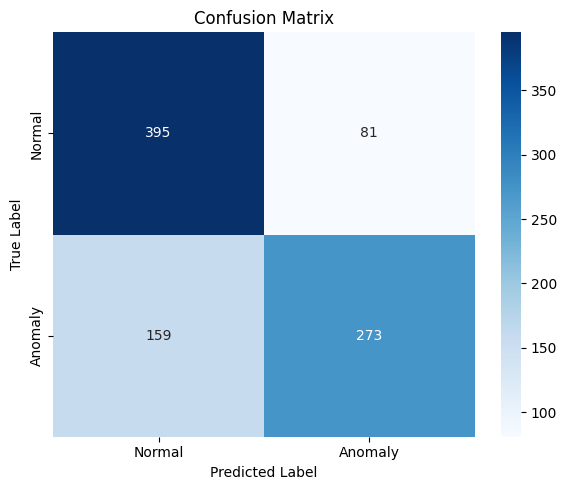

In [15]:
import tensorflow as tf
import numpy as np
import cv2
import os
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

print(f"Using TensorFlow version: {tf.__version__}")

## 1. Configuration & Model Loading
# ==============================================================================
# --- Parameters ---
IMAGE_SIZE = (224, 224)
TEST_DATA_DIR = r'C:\Users\User\Downloads\Skin-disease-dataset\anomaly-test'

# --- Model File Paths ---
GANOMALY_GENERATOR_PATH = "ganomaly_generator.h5"
# ❗ IMPORTANT: Update this to the path of your custom classifier model.
CLASSIFIER_MODEL_PATH = "four_skin_disease_detection.h5" 

# --- Thresholds ---
# Step 1: GANomaly reconstruction error threshold.
ANOMALY_THRESHOLD = 0.1
# Step 2: Classifier confidence threshold.
# If GANomaly flags an anomaly, it's only confirmed if the classifier's
# confidence is LESS THAN this value.
CONFIDENCE_THRESHOLD = 0.90 

# --- Load Models ---
try:
    # Load the GANomaly generator (autoencoder) for reconstruction.
    generator = tf.keras.models.load_model(GANOMALY_GENERATOR_PATH, compile=False)
    print("✅ GANomaly generator loaded successfully.")
    
    # Load your custom classifier for the second validation step.
    classifier_model = tf.keras.models.load_model(CLASSIFIER_MODEL_PATH, compile=False)
    print("✅ Custom classifier loaded successfully.")

except Exception as e:
    print(f"❌ Error loading models: {e}")
    print("Please ensure the .h5 files exist and the paths are correct.")
    exit()

## 2. Helper Functions
# ==============================================================================
def preprocess_image(image_path: str, size: tuple) -> np.ndarray:
    """Loads, resizes, and normalizes an image."""
    img = cv2.imread(image_path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    
    # ❗ IMPORTANT: This normalizes images to [-1, 1].
    # Ensure this is the correct preprocessing for BOTH your models.
    # If your classifier expects [0, 1], you may need a separate preprocessing step.
    img = (img.astype(np.float32) - 127.5) / 127.5
    
    return np.expand_dims(img, axis=0)

def calculate_anomaly_score(original_img: np.ndarray) -> float:
    """Calculates the reconstruction error (L1/MAE) as the anomaly score."""
    reconstructed_img = generator.predict(original_img, verbose=0)
    reconstruction_error = np.mean(np.abs(original_img - reconstructed_img))
    return float(reconstruction_error)

def plot_confusion_matrix(y_true, y_pred, class_names):
    """Generates and displays a confusion matrix plot."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

## 3. Main Evaluation Logic
# ==============================================================================
y_true = [] # Ground truth labels (0 for Normal, 1 for Anomaly)
y_pred = [] # Predicted labels
scores = [] # Anomaly scores from GANomaly

def evaluate_directory(image_files, true_label, description):
    """Processes a directory of images using the two-step validation logic."""
    for file_path in tqdm(image_files, desc=description):
        image_tensor = preprocess_image(file_path, IMAGE_SIZE)
        if image_tensor is None:
            continue

        # --- Step 1: Anomaly Detection (GANomaly) ---
        anomaly_score = calculate_anomaly_score(image_tensor)
        
        # Default prediction is Normal (0)
        final_prediction = 0 
        
        # If the reconstruction error is high, it's a *potential* anomaly.
        if anomaly_score > ANOMALY_THRESHOLD:
            # --- Step 2: Verification with Classifier ---
            # Now, use the second model to get a confidence score.
            classifier_predictions = classifier_model.predict(image_tensor, verbose=0)
            confidence = np.max(classifier_predictions)
            
            # If the classifier is NOT confident, we confirm it's an anomaly.
            if confidence < CONFIDENCE_THRESHOLD:
                final_prediction = 1 # Confirmed Anomaly
            # Otherwise, we override the GANomaly result and keep it as Normal (0).
        
        y_true.append(true_label)
        y_pred.append(final_prediction)
        scores.append(anomaly_score)

# --- Process Normal Images ---
normal_path = os.path.join(TEST_DATA_DIR, 'Normal')
normal_files = [os.path.join(normal_path, f) for f in os.listdir(normal_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
print(f"\nProcessing {len(normal_files)} NORMAL images...")
evaluate_directory(normal_files, true_label=0, description="Normal Images")


# --- Process Anomaly Images ---
anomaly_path = os.path.join(TEST_DATA_DIR, 'Anomaly')
anomaly_files = [os.path.join(anomaly_path, f) for f in os.listdir(anomaly_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
print(f"\nProcessing {len(anomaly_files)} ANOMALY images...")
evaluate_directory(anomaly_files, true_label=1, description="Anomaly Images")

## 4. Report Results
# ==============================================================================
if not y_true:
    print("\n❌ No images found in the test directory. Please check your folder structure.")
else:
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    
    # Ensure cm is 2x2 for unpacking
    if cm.shape == (1, 1):
        if np.unique(y_true)[0] == 0: # Only negatives
            tn, fp, fn, tp = cm[0][0], 0, 0, 0
        else: # Only positives
            tn, fp, fn, tp = 0, 0, 0, cm[0][0]
    else:
        tn, fp, fn, tp = cm.ravel()

    print("\n" + "="*50)
    print("📊 Evaluation Results (Two-Step Verification)")
    print("="*50)
    print(f"GANomaly Anomaly Threshold: {ANOMALY_THRESHOLD}")
    print(f"Classifier Confidence Threshold: < {CONFIDENCE_THRESHOLD}\n")
    print(f"True Negatives (Normal -> Normal):     {tn}")
    print(f"False Positives (Normal -> Anomaly):   {fp}")
    print(f"False Negatives (Anomaly -> Normal):   {fn}")
    print(f"True Positives (Anomaly -> Anomaly):   {tp}")
    print("-"*50)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("="*50)
    
    plot_confusion_matrix(y_true, y_pred, class_names=['Normal', 'Anomaly'])